#Dataset Load & split

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [18]:
df = pd.read_csv('/content/heart_disease_cleaned.csv')
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0


In [19]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state=42)

In [21]:
y_train.value_counts()

,count
TenYearCHD,
0,2870
1,520


#Imbalanced Dataset

A class imbalance occurs when the target variable has significantly different numbers of observations across its classes.

No Churn---->███████████████████████████████████████████████  95%<br>
Churn------->███                                               5%

# Problem

Assume there are 100 test results, out of which
* 95 patient actual has no heart disease
* 5 patient has actual heart disease

model prediction:
90 has no disease out of 95 and says 5 has disease
1 has disease out of 5 and say 4 has no disease

Overall 91 is correct out of 100, so accuracy is 91%
but if we look deeper, it predicted only 1 as +ve out of 5 patient, so if disease patient take test, machine will class wrongly almost 80% time

This is why we need to look at metrics such as:

* Precision
* Recall
* F1 Score
* ROC-AUC
* PR-AUC, especially for severe imbalance

# Detect class Imbalance

* `df['Target_column'].value_count()`
* `df['Target_column'].value_count(normalize=True) * 100`

In [22]:
df['TenYearCHD'].value_counts()

,count
TenYearCHD,
0,3594
1,644


In [23]:
df['TenYearCHD'].value_counts(normalize=True)*100

,proportion
TenYearCHD,
0,84.804153
1,15.195847


# How to Handling

In [24]:
  #               Class Imbalance
  #                      │
  #         ┌────────────┴────────────────────────────┐────────────────────┐
  #         │                                         │                    │
  #  Data-level Methods                       Model-level Methods    Decision-Level
  #  (Resampling)                             (Class Weight)         (Threshold Moving)
  #         │
  #    ┌────┼─────────┐────────┐
  #    │    │         │        │
  #   RUS  ROS      SMOTE    SMOTE-ENN
  #                            │
  #                          SMOTE-TOMEK


## Data Level

### RUS

**Idea**

Reduce the number of observations in the majority class.

**Advantages**
* Faster training
* Creates a balanced dataset
* Useful when the majority class is extremely large

**Disadvantages**
* Removes data
* May remove useful information
* Can reduce model performance if important observations are discarded

In [25]:
from imblearn.under_sampling import RandomUnderSampler

In [26]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

In [27]:
y_train_rus.value_counts()

,count
TenYearCHD,
0,520
1,520


### ROS

**Idea**

Increase the number of observations in the minority class by randomly duplicating existing minority observations.

**Advantages**
* Doesn't remove majority data
* Simple
* Easy to implement

**Disadvantages**
* Duplicating observations can cause overfitting
* Dataset becomes larger

In [28]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

In [29]:
y_train_ros.value_counts()

,count
TenYearCHD,
0,2870
1,2870


### SMOTE

**SMOTE = Synthetic Minority Over-sampling Technique**

Instead of simply duplicating minority observations, SMOTE creates new synthetic observations.

In [30]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [31]:
y_train_smote.value_counts()

,count
TenYearCHD,
0,2870
1,2870


### SMOTE-ENN

**SMOTEENN = SMOTE + Edited Nearest Neighbours (ENN)**

It combines:

**SMOTE** → creates synthetic minority samples<BR>
**ENN** → removes samples that appear to be incorrectly classified based on their nearest neighbours

In [32]:
from imblearn.combine import SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)

In [33]:
y_train_smoteenn.value_counts()

,count
TenYearCHD,
1,2653
0,1561


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smoteenn)
X_test_scaled = scaler.transform(X_test)

In [35]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_smoteenn)

LogisticRegression()

In [36]:
y_predict = log_model.predict(X_test_scaled)
accu_score = accuracy_score(y_test, y_predict)

In [37]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.48      0.62       724
           1       0.19      0.73      0.30       124

    accuracy                           0.51       848
   macro avg       0.55      0.60      0.46       848
weighted avg       0.80      0.51      0.58       848



### SMOTE-TOMEK

**SMOTETomek = SMOTE + Tomek Links**

It combines:

**SMOTE** → creates synthetic minority samples<BR>
**Tomek Links** → identifies and removes overlapping/borderline samples

In [38]:
from imblearn.combine import SMOTETomek
smotetomek = SMOTETomek(random_state=42)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(X_train, y_train)

In [39]:
y_train_smotetomek.value_counts()

,count
TenYearCHD,
0,2839
1,2839


In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smotetomek)
X_test_scaled = scaler.transform(X_test)

In [41]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train_smotetomek)

LogisticRegression()

In [42]:
y_predict = log_model.predict(X_test_scaled)

In [43]:
acc_score = accuracy_score(y_test, y_predict)
acc_score

0.6297169811320755

In [44]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75       724
           1       0.19      0.46      0.27       124

    accuracy                           0.63       848
   macro avg       0.53      0.56      0.51       848
weighted avg       0.78      0.63      0.68       848



### ADASYN

In [45]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

In [46]:
y_train_adasyn.value_counts()

,count
TenYearCHD,
1,2902
0,2870


In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_adasyn)
X_test_scaled = scaler.transform(X_test)

In [48]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train_adasyn)

LogisticRegression()

In [49]:
y_predict = model.predict(X_test_scaled)

In [50]:
acc_score = accuracy_score(y_test, y_predict)
acc_score

0.6238207547169812

In [51]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.88      0.65      0.75       724
           1       0.19      0.48      0.27       124

    accuracy                           0.62       848
   macro avg       0.53      0.56      0.51       848
weighted avg       0.78      0.62      0.68       848



# Model - Level

In [52]:
len(X_train_scaled)

5772

In [53]:
len(y_train_smotetomek)

5678

In [54]:
log_model = LogisticRegression(class_weight='balanced')
log_model.fit(X_train_scaled, y_train_adasyn)

LogisticRegression(class_weight='balanced')

# Decision - Level

In [55]:
y_default_pred = log_model.predict(X_test_scaled)

In [56]:
y_default_pred

array([1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,

In [57]:
y_default_pred_copy = y_default_pred.copy().tolist()

In [58]:
print(y_default_pred_copy.count(0),y_default_pred_copy.count(1))

538 310


## Change Threshold

In [59]:
y_prob = log_model.predict_proba(X_test_scaled)
threshold = 0.30
y_pred_threshold = (y_prob >= threshold).astype(int)

In [60]:
y_pred_threshold

array([[1, 1],
       [1, 1],
       [1, 1],
       ...,
       [1, 1],
       [0, 1],
       [1, 1]])

In [61]:
y_pred_threshold_copy = y_pred_threshold.copy().tolist()

In [62]:
y_pred_threshold_copy

[[1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [0, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [0, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [0, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [0, 1],
 [1, 1],
 [0, 1],
 [1, 0],
 [1, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [1, 1],
 [0, 1],
 [1, 0],
 [0, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [0, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [1, 0],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 0],
 [1, 0],
 [0, 1],
 [1, 1],
 [1, 1],
 [1, 0],
 [1, 1],
 [1, 1],
 

In [63]:
for i in range(len(y_pred_threshold_copy)):
  y_pred_threshold_copy[i] = y_pred_threshold_copy[i][0]

In [64]:
print(y_pred_threshold_copy.count(0),y_pred_threshold_copy.count(1))

96 752


In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [66]:
print(precision_score(y_test, y_pred_threshold_copy))
print(recall_score(y_test, y_pred_threshold_copy))
print(f1_score(y_test, y_pred_threshold_copy))

0.1356382978723404
0.8225806451612904
0.2328767123287671


In [67]:
from sklearn.metrics import roc_curve, roc_auc_score

In [68]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])

In [69]:
thresholds

array([       inf, 0.93595406, 0.93511677, 0.86203511, 0.85946828,
       0.85175207, 0.8512755 , 0.83035075, 0.82898666, 0.82882464,
       0.81502045, 0.81392612, 0.80691888, 0.80175278, 0.8008076 ,
       0.79438047, 0.79412598, 0.79323057, 0.79125326, 0.75728726,
       0.75637282, 0.75131574, 0.74736983, 0.73836182, 0.7380345 ,
       0.73525803, 0.73523158, 0.7346049 , 0.73352722, 0.72317519,
       0.72128754, 0.71762537, 0.71499721, 0.70553528, 0.70445372,
       0.7034445 , 0.70215404, 0.70100542, 0.70017347, 0.69819373,
       0.69647769, 0.68696228, 0.68507486, 0.66776941, 0.66757016,
       0.65104841, 0.64632141, 0.64008126, 0.6400278 , 0.63959791,
       0.639189  , 0.63877498, 0.63841248, 0.63584621, 0.63492841,
       0.63432946, 0.62999929, 0.62460368, 0.62149097, 0.60025004,
       0.59979136, 0.59967488, 0.59902857, 0.59273185, 0.59240373,
       0.58786452, 0.58773476, 0.58220229, 0.58213969, 0.58186407,
       0.58161334, 0.5774632 , 0.57497332, 0.57484658, 0.57479

In [70]:
fpr

array([0.        , 0.        , 0.        , 0.01243094, 0.01243094,
       0.01381215, 0.01381215, 0.02486188, 0.02486188, 0.02624309,
       0.02624309, 0.02762431, 0.02762431, 0.03314917, 0.03314917,
       0.03867403, 0.03867403, 0.04005525, 0.04005525, 0.05801105,
       0.05801105, 0.06353591, 0.06353591, 0.07044199, 0.07044199,
       0.07320442, 0.07320442, 0.07458564, 0.07458564, 0.08149171,
       0.08149171, 0.08563536, 0.08563536, 0.09668508, 0.09668508,
       0.09944751, 0.09944751, 0.10220994, 0.10220994, 0.10497238,
       0.10497238, 0.1160221 , 0.1160221 , 0.13950276, 0.13950276,
       0.15607735, 0.15607735, 0.16298343, 0.16298343, 0.16436464,
       0.16436464, 0.16574586, 0.16574586, 0.1698895 , 0.1698895 ,
       0.17127072, 0.17127072, 0.17679558, 0.17679558, 0.20165746,
       0.20165746, 0.20303867, 0.20303867, 0.21546961, 0.21546961,
       0.22375691, 0.22375691, 0.23895028, 0.23895028, 0.24033149,
       0.24033149, 0.24447514, 0.24447514, 0.24723757, 0.24723

In [71]:
tpr

array([0.        , 0.00806452, 0.01612903, 0.01612903, 0.03225806,
       0.03225806, 0.04032258, 0.04032258, 0.0483871 , 0.0483871 ,
       0.05645161, 0.05645161, 0.06451613, 0.06451613, 0.07258065,
       0.07258065, 0.08064516, 0.08064516, 0.08870968, 0.08870968,
       0.09677419, 0.09677419, 0.10483871, 0.10483871, 0.11290323,
       0.11290323, 0.12096774, 0.12096774, 0.12903226, 0.12903226,
       0.14516129, 0.14516129, 0.15322581, 0.15322581, 0.16129032,
       0.16129032, 0.16935484, 0.16935484, 0.17741935, 0.17741935,
       0.19354839, 0.19354839, 0.20967742, 0.20967742, 0.21774194,
       0.21774194, 0.24193548, 0.24193548, 0.25      , 0.25      ,
       0.25806452, 0.25806452, 0.26612903, 0.26612903, 0.27419355,
       0.27419355, 0.28225806, 0.28225806, 0.29032258, 0.29032258,
       0.2983871 , 0.2983871 , 0.30645161, 0.30645161, 0.31451613,
       0.31451613, 0.32258065, 0.32258065, 0.33064516, 0.33064516,
       0.33870968, 0.33870968, 0.35483871, 0.35483871, 0.36290

Text(0.5, 1.0, 'ROC Curve')

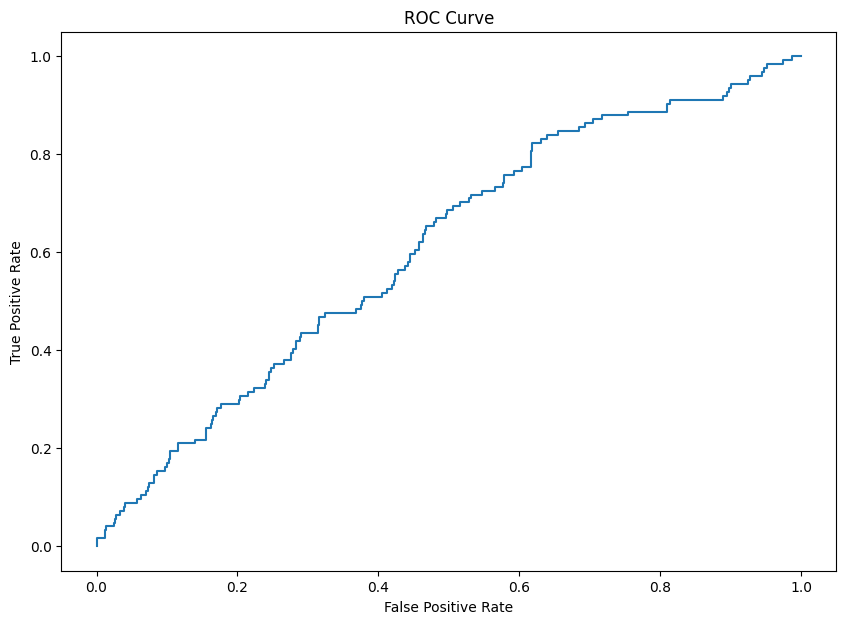

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

In [73]:
roc_auc_rate = roc_auc_score(y_test, y_prob[:,1])

In [74]:
roc_auc_rate

np.float64(0.6073226697558367)

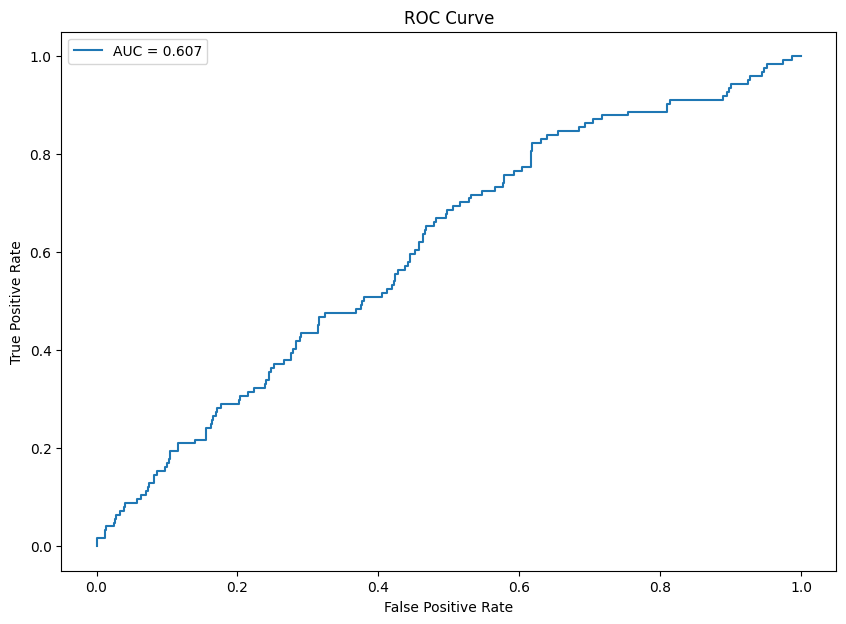

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot(fpr, tpr, label = f"AUC = {roc_auc_rate:.3f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()